# Notebook 1: Exploración Inicial y Transformación de Datos

En este notebook:
1. Cargamos y exploramos el dataset original (datos mensuales)
2. Transformamos los datos de mensuales a anuales
3. Agregamos features de clima (12 features por mes)
4. Guardamos el dataset procesado para los siguientes análisis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

import warnings
warnings.filterwarnings('ignore')

## 1. Carga y Exploración Inicial del Dataset

In [2]:
df = pd.read_csv('../dataset_final_clima_completo.csv')
print(f"Shape del dataset original: {df.shape}")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nPrimeras filas:")
df.head(10)

Shape del dataset original: (1441934, 15)

Columnas: ['provincia_nombre', 'departamento_nombre', 'departamento_id', 'cultivo', 'año', 'mes', 'rendimiento', 'temperatura_celsius', 'precipitacion_mm', 'suelo_ind_prod', 'suelo_porc_sue1', 'suelo_profund_s1', 'suelo_alcalin_s1', 'produccion', 'sup_sembrada']

Primeras filas:


,provincia_nombre,departamento_nombre,departamento_id,cultivo,año,mes,rendimiento,temperatura_celsius,precipitacion_mm,suelo_ind_prod,suelo_porc_sue1,suelo_profund_s1,suelo_alcalin_s1,produccion,sup_sembrada
0,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,1,3333,22.368317,5.617142,34.550898,66.545659,77.879491,No sodico,10,3
1,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,2,3333,23.294342,1.991272,34.550898,66.545659,77.879491,No sodico,10,3
2,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,3,3333,19.947906,6.193161,34.550898,66.545659,77.879491,No sodico,10,3
3,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,4,3333,18.099762,3.725052,34.550898,66.545659,77.879491,No sodico,10,3
4,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,5,3333,12.083649,0.638962,34.550898,66.545659,77.879491,No sodico,10,3
5,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,6,3333,8.224274,0.946045,34.550898,66.545659,77.879491,No sodico,10,3
6,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,7,3333,8.897369,0.991821,34.550898,66.545659,77.879491,No sodico,10,3
7,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,8,3333,9.852448,0.617981,34.550898,66.545659,77.879491,No sodico,10,3
8,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,9,3333,14.838287,1.853943,34.550898,66.545659,77.879491,No sodico,10,3
9,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,10,3333,14.759918,1.792908,34.550898,66.545659,77.879491,No sodico,10,3


In [3]:
print("Información del dataset:")
df.info()

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441934 entries, 0 to 1441933
Data columns (total 15 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   provincia_nombre     1441934 non-null  object 
 1   departamento_nombre  1441934 non-null  object 
 2   departamento_id      1441934 non-null  object 
 3   cultivo              1441934 non-null  object 
 4   año                  1441934 non-null  int64  
 5   mes                  1441934 non-null  int64  
 6   rendimiento          1441934 non-null  int64  
 7   temperatura_celsius  1441934 non-null  float64
 8   precipitacion_mm     1441934 non-null  float64
 9   suelo_ind_prod       1441934 non-null  float64
 10  suelo_porc_sue1      1441934 non-null  float64
 11  suelo_profund_s1     1441934 non-null  float64
 12  suelo_alcalin_s1     1441934 non-null  object 
 13  produccion           1441934 non-null  int64  
 14  sup_sembrada         1441

In [4]:
print("Estadísticas descriptivas:")
df.describe()

Estadísticas descriptivas:


,año,mes,rendimiento,temperatura_celsius,precipitacion_mm,suelo_ind_prod,suelo_porc_sue1,suelo_profund_s1,produccion,sup_sembrada
count,1.441934e+06,1.441934e+06,1.441934e+06,1.441934e+06,1.441934e+06,1.441934e+06,1.441934e+06,1.441934e+06,1.441934e+06,1.441934e+06
mean,1.994304e+03,6.484028e+00,3.126653e+03,1.771922e+01,3.009760e+00,2.929989e+01,6.584686e+01,9.607569e+01,2.787233e+04,9.422484e+03
std,1.696072e+01,3.445842e+00,5.319137e+03,5.677643e+00,2.642622e+00,7.962957e+00,8.890645e+00,7.152345e+01,1.210287e+05,2.747780e+04
min,1.970000e+03,1.000000e+00,0.000000e+00,-1.482578e+01,0.000000e+00,9.129310e+00,4.930070e+01,5.240964e+01,0.000000e+00,0.000000e+00
25%,1.979000e+03,3.000000e+00,9.000000e+02,1.340420e+01,1.108170e+00,2.109000e+01,6.219008e+01,7.496154e+01,1.600000e+02,2.000000e+02
50%,1.991000e+03,6.000000e+00,1.800000e+03,1.810220e+01,2.368927e+00,3.455090e+01,6.654566e+01,7.787949e+01,1.512000e+03,1.400000e+03
75%,2.010000e+03,9.000000e+00,3.307000e+03,2.231192e+01,4.144669e+00,3.455090e+01,6.669944e+01,8.215702e+01,1.100000e+04,7.043000e+03
max,2.025000e+03,1.200000e+01,1.324050e+05,3.284927e+01,2.993011e+01,4.825735e+01,8.700000e+01,3.895105e+02,8.620000e+06,8.592730e+05


In [5]:
print(f"Cantidad de valores nulos por columna:")
print(df.isnull().sum())
print(f"\nPorcentaje de valores nulos:")
print((df.isnull().sum() / len(df) * 100).round(2))

Cantidad de valores nulos por columna:
provincia_nombre       0
departamento_nombre    0
departamento_id        0
cultivo                0
año                    0
mes                    0
rendimiento            0
temperatura_celsius    0
precipitacion_mm       0
suelo_ind_prod         0
suelo_porc_sue1        0
suelo_profund_s1       0
suelo_alcalin_s1       0
produccion             0
sup_sembrada           0
dtype: int64

Porcentaje de valores nulos:
provincia_nombre       0.0
departamento_nombre    0.0
departamento_id        0.0
cultivo                0.0
año                    0.0
mes                    0.0
rendimiento            0.0
temperatura_celsius    0.0
precipitacion_mm       0.0
suelo_ind_prod         0.0
suelo_porc_sue1        0.0
suelo_profund_s1       0.0
suelo_alcalin_s1       0.0
produccion             0.0
sup_sembrada           0.0
dtype: float64


In [6]:
print(f"Cantidad de cultivos únicos: {df['cultivo'].nunique()}")
print(f"Cultivos: {df['cultivo'].unique()}")
print(f"\nCantidad de departamentos únicos: {df['departamento_id'].nunique()}")
print(f"\nRango de años: {df['año'].min()} - {df['año'].max()}")
print(f"Meses: {sorted(df['mes'].unique())}")

Cantidad de cultivos únicos: 34
Cultivos: ['Ajo' 'Algodón' 'Alpiste' 'Arroz' 'Arveja' 'Avena' 'Banana'
 'Caña de azúcar' 'Cártamo' 'Cebada cervecera' 'Cebada forrajera'
 'Centeno' 'Colza' 'Garbanzo' 'Girasol' 'Jojoba' 'Lenteja' 'Limón' 'Lino'
 'Maíz' 'Mandarina' 'Maní' 'Mijo' 'Naranja' 'Pomelo' 'Poroto alubia'
 'Poroto negro' 'Soja 1ra' 'Soja 2da' 'Sorgo' 'Té' 'Trigo candeal' 'Tung'
 'Yerba mate']

Cantidad de departamentos únicos: 483

Rango de años: 1970 - 2025
Meses: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


In [7]:
print("Distribución de registros por cultivo:")
print(df['cultivo'].value_counts())

Distribución de registros por cultivo:
cultivo
Maíz                211574
Sorgo               144640
Avena               137508
Girasol             127130
Cebada forrajera     78840
Soja 1ra             76590
Centeno              72046
Soja 2da             60744
Cebada cervecera     53100
Algodón              51750
Ajo                  48960
Lino                 47794
Naranja              36288
Mijo                 31740
Mandarina            29748
Alpiste              26864
Limón                26712
Arroz                24568
Maní                 24018
Pomelo               23916
Colza                19028
Caña de azúcar       15492
Trigo candeal        14804
Yerba mate           12588
Té                   11844
Tung                  8172
Arveja                6142
Cártamo               5866
Banana                5172
Garbanzo              3554
Poroto negro          2090
Lenteja               1724
Poroto alubia          688
Jojoba                 240
Name: count, dtype: int64


## 2. Limpieza de Datos

In [8]:
print(f"Registros antes de limpieza: {len(df)}")

df_clean = df.dropna(subset=['rendimiento'])
print(f"Registros después de eliminar nulos en rendimiento: {len(df_clean)}")

df_clean = df_clean[df_clean['rendimiento'] > 0]
print(f"Registros después de eliminar rendimientos <= 0: {len(df_clean)}")

Registros antes de limpieza: 1441934
Registros después de eliminar nulos en rendimiento: 1441934
Registros después de eliminar rendimientos <= 0: 1250916


In [9]:
numeric_cols = ['temperatura_celsius', 'precipitacion_mm', 'suelo_ind_prod', 
                'suelo_porc_sue1', 'suelo_profund_s1', 'produccion', 'sup_sembrada']

for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"Imputados {col} con mediana: {median_val}")

## 3. Transformación de Datos Mensuales a Anuales

Vamos a transformar el dataset para que cada muestra sea anual:
- Agregamos 12 features por cada variable climática (una por mes)
- Mantenemos las features de suelo y cultivo (son constantes por año)
- El rendimiento será el target anual

In [10]:
def transform_monthly_to_annual(df):
    """
    Transforma el dataset de registros mensuales a registros anuales.
    Cada año tendrá 12 features de temperatura y 12 de precipitación (una por mes).
    """
    
    print("Iniciando transformación de datos mensuales a anuales...")
    
    grouping_cols = ['provincia_nombre', 'departamento_nombre', 'departamento_id', 
                     'cultivo', 'año']
    
    annual_data = []
    
    for name, group in df.groupby(grouping_cols):
        row_dict = {
            'provincia_nombre': name[0],
            'departamento_nombre': name[1],
            'departamento_id': name[2],
            'cultivo': name[3],
            'año': name[4]
        }
        
        for mes in range(1, 13):
            mes_data = group[group['mes'] == mes]
            
            if len(mes_data) > 0:
                row_dict[f'temperatura_mes_{mes}'] = mes_data['temperatura_celsius'].mean()
                row_dict[f'precipitacion_mes_{mes}'] = mes_data['precipitacion_mm'].mean()
            else:
                row_dict[f'temperatura_mes_{mes}'] = np.nan
                row_dict[f'precipitacion_mes_{mes}'] = np.nan
        
        row_dict['suelo_ind_prod'] = group['suelo_ind_prod'].iloc[0]
        row_dict['suelo_porc_sue1'] = group['suelo_porc_sue1'].iloc[0]
        row_dict['suelo_profund_s1'] = group['suelo_profund_s1'].iloc[0]
        row_dict['suelo_alcalin_s1'] = group['suelo_alcalin_s1'].iloc[0]
        
        row_dict['produccion_total'] = group['produccion'].sum()
        row_dict['sup_sembrada_total'] = group['sup_sembrada'].mean()
        
        row_dict['rendimiento'] = group['rendimiento'].mean()
        
        annual_data.append(row_dict)
    
    df_annual = pd.DataFrame(annual_data)
    
    print(f"Transformación completada. Shape: {df_annual.shape}")
    return df_annual

In [11]:
df_annual = transform_monthly_to_annual(df_clean)
print(f"\nDataset anual creado con shape: {df_annual.shape}")
df_annual.head()



Iniciando transformación de datos mensuales a anuales...
Transformación completada. Shape: (104607, 36)

Dataset anual creado con shape: (104607, 36)


,provincia_nombre,departamento_nombre,departamento_id,cultivo,año,temperatura_mes_1,precipitacion_mes_1,temperatura_mes_2,precipitacion_mes_2,temperatura_mes_3,...,precipitacion_mes_11,temperatura_mes_12,precipitacion_mes_12,suelo_ind_prod,suelo_porc_sue1,suelo_profund_s1,suelo_alcalin_s1,produccion_total,sup_sembrada_total,rendimiento
0,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,22.368317,5.617142,23.294342,1.991272,19.947906,...,1.723289,21.553620,2.273560,34.550898,66.545659,77.879491,No sodico,120,3.0,3333.0
1,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1971,21.483307,4.999161,19.945220,1.067162,19.613190,...,1.073837,23.387360,3.779411,34.550898,66.545659,77.879491,No sodico,36,1.0,3000.0
2,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Alpiste,1970,22.368317,5.617142,23.294342,1.991272,19.947906,...,1.723289,21.553620,2.273560,34.550898,66.545659,77.879491,No sodico,2880,500.0,600.0
3,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Alpiste,1971,21.483307,4.999161,19.945220,1.067162,19.613190,...,1.073837,23.387360,3.779411,34.550898,66.545659,77.879491,No sodico,936,150.0,600.0
4,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Alpiste,1976,22.507720,7.625580,21.946686,6.154060,17.001617,...,2.634049,20.727936,4.756927,34.550898,66.545659,77.879491,No sodico,3780,350.0,900.0


In [12]:
print("Información del dataset anual:")
df_annual.info()

Información del dataset anual:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104607 entries, 0 to 104606
Data columns (total 36 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   provincia_nombre      104607 non-null  object 
 1   departamento_nombre   104607 non-null  object 
 2   departamento_id       104607 non-null  object 
 3   cultivo               104607 non-null  object 
 4   año                   104607 non-null  int64  
 5   temperatura_mes_1     104607 non-null  float64
 6   precipitacion_mes_1   104607 non-null  float64
 7   temperatura_mes_2     104607 non-null  float64
 8   precipitacion_mes_2   104607 non-null  float64
 9   temperatura_mes_3     104607 non-null  float64
 10  precipitacion_mes_3   104607 non-null  float64
 11  temperatura_mes_4     104607 non-null  float64
 12  precipitacion_mes_4   104607 non-null  float64
 13  temperatura_mes_5     104607 non-null  float64
 14  precipitacion_mes_5  

In [13]:
print(f"Valores nulos en dataset anual:")
print(df_annual.isnull().sum().sort_values(ascending=False).head(20))

Valores nulos en dataset anual:
temperatura_mes_12      2184
precipitacion_mes_11    2184
temperatura_mes_11      2184
precipitacion_mes_12    2184
precipitacion_mes_8        0
temperatura_mes_9          0
precipitacion_mes_9        0
temperatura_mes_10         0
precipitacion_mes_10       0
provincia_nombre           0
departamento_nombre        0
suelo_ind_prod             0
suelo_porc_sue1            0
suelo_profund_s1           0
suelo_alcalin_s1           0
produccion_total           0
sup_sembrada_total         0
temperatura_mes_8          0
precipitacion_mes_7        0
temperatura_mes_7          0
dtype: int64


## 4. Imputación de Valores Faltantes en Dataset Anual

In [14]:
for mes in range(1, 13):
    col_temp = f'temperatura_mes_{mes}'
    col_precip = f'precipitacion_mes_{mes}'
    
    if df_annual[col_temp].isnull().sum() > 0:
        df_annual[col_temp].fillna(df_annual[col_temp].median(), inplace=True)
    
    if df_annual[col_precip].isnull().sum() > 0:
        df_annual[col_precip].fillna(df_annual[col_precip].median(), inplace=True)

print("Imputación de valores climáticos completada.")
print(f"\nValores nulos restantes: {df_annual.isnull().sum().sum()}")

Imputación de valores climáticos completada.

Valores nulos restantes: 0


## 5. Codificación de Variables Categóricas

In [15]:
from sklearn.preprocessing import LabelEncoder

le_cultivo = LabelEncoder()
df_annual['cultivo_encoded'] = le_cultivo.fit_transform(df_annual['cultivo'])

le_alcalin = LabelEncoder()
df_annual['suelo_alcalin_encoded'] = le_alcalin.fit_transform(df_annual['suelo_alcalin_s1'])

df_annual.to_csv('../data/processed/dataset_anual_encoded.csv', index=False)
print("Dataset anual guardado en '../data/processed/dataset_anual_encoded.csv'")

print("Codificación de variables categóricas completada.")
print(f"\nCultivos codificados:")
for i, cultivo in enumerate(le_cultivo.classes_):
    print(f"  {i}: {cultivo}")

print(f"\nAlcalinidad codificada:")
for i, alcalin in enumerate(le_alcalin.classes_):
    print(f"  {i}: {alcalin}")

Dataset anual guardado en '../data/processed/dataset_anual_encoded.csv'
Codificación de variables categóricas completada.

Cultivos codificados:
  0: Ajo
  1: Algodón
  2: Alpiste
  3: Arroz
  4: Arveja
  5: Avena
  6: Banana
  7: Caña de azúcar
  8: Cebada cervecera
  9: Cebada forrajera
  10: Centeno
  11: Colza
  12: Cártamo
  13: Garbanzo
  14: Girasol
  15: Jojoba
  16: Lenteja
  17: Limón
  18: Lino
  19: Mandarina
  20: Maní
  21: Maíz
  22: Mijo
  23: Naranja
  24: Pomelo
  25: Poroto alubia
  26: Poroto negro
  27: Soja 1ra
  28: Soja 2da
  29: Sorgo
  30: Trigo candeal
  31: Tung
  32: Té
  33: Yerba mate

Alcalinidad codificada:
  0: -
  1: Debil
  2: No salino
  3: No sodico


## 6. Estadísticas del Dataset Transformado

In [16]:
print(f"Total de muestras anuales: {len(df_annual)}")
print(f"Total de features: {df_annual.shape[1]}")
print(f"\nDistribución por año:")
print(df_annual['año'].value_counts().sort_index())

Total de muestras anuales: 104607
Total de features: 38

Distribución por año:
año
1970    2181
1971    2151
1972    2106
1973    2108
1974    2090
1975    2050
1976    2045
1977    2567
1978    2584
1979    2613
1980    2601
1981    2511
1982    2389
1983    2428
1984    2374
1985    2359
1986    2253
1987    2036
1988    1930
1989    1370
1990    1776
1991    1339
1992    1496
1993    1565
1994    1612
1995    1621
1996    1616
1997    1648
1998    1365
1999    1252
2000    1173
2001    1483
2002    1477
2003    1454
2004    1606
2005    1574
2006    1596
2007    1625
2008    1757
2009    1662
2010    1707
2011    1761
2012    1718
2013    1775
2014    1770
2015    1753
2016    1704
2017    1552
2018    1527
2019    1664
2020    1775
2021    1916
2022    2097
2023    2098
2024    2163
2025    2184
Name: count, dtype: int64


In [17]:
print("Distribución por cultivo:")
print(df_annual['cultivo'].value_counts())

Distribución por cultivo:
cultivo
Maíz                17129
Sorgo               11476
Girasol             10599
Avena                7658
Soja 1ra             6401
Soja 2da             5081
Algodón              4286
Cebada cervecera     4174
Ajo                  4070
Lino                 3959
Centeno              3541
Cebada forrajera     2495
Alpiste              2234
Mijo                 2233
Arroz                2052
Naranja              2038
Maní                 1986
Mandarina            1678
Colza                1570
Limón                1535
Pomelo               1395
Trigo candeal        1245
Caña de azúcar       1134
Yerba mate           1039
Té                    961
Tung                  650
Arveja                518
Cártamo               478
Garbanzo              304
Banana                284
Poroto negro          181
Lenteja               143
Poroto alubia          60
Jojoba                 20
Name: count, dtype: int64


Estadísticas del rendimiento (variable objetivo):
count    104607.000000
mean       3601.806007
std        5549.686831
min           8.000000
25%        1200.000000
50%        2100.000000
75%        3730.000000
max      132405.000000
Name: rendimiento, dtype: float64


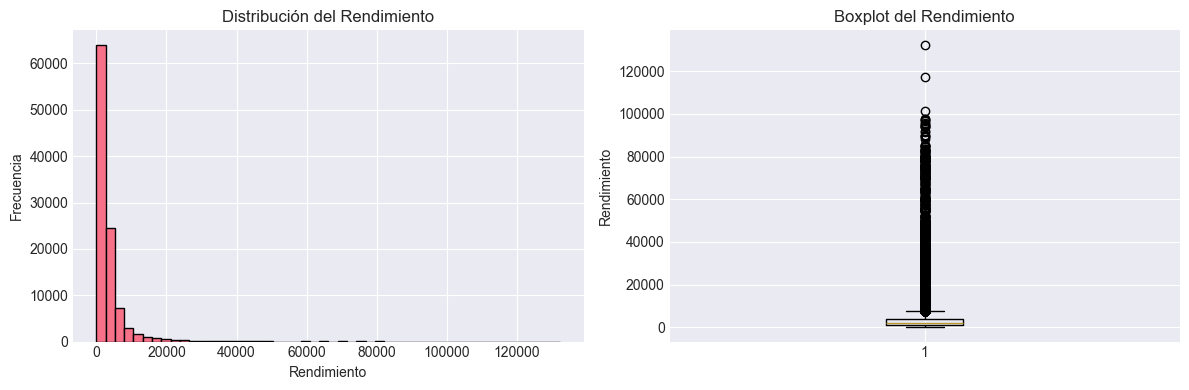

In [18]:
print("Estadísticas del rendimiento (variable objetivo):")
print(df_annual['rendimiento'].describe())

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df_annual['rendimiento'], bins=50, edgecolor='black')
plt.xlabel('Rendimiento')
plt.ylabel('Frecuencia')
plt.title('Distribución del Rendimiento')

plt.subplot(1, 2, 2)
plt.boxplot(df_annual['rendimiento'])
plt.ylabel('Rendimiento')
plt.title('Boxplot del Rendimiento')

plt.tight_layout()
plt.savefig('../figures/distribucion_rendimiento.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Guardar Dataset Procesado

In [19]:
# Ordenar por año para asegurar orden cronológico
df_annual_sorted = df_annual.sort_values('año').reset_index(drop=True)

# Calcular punto de división 80/20 por años
años_unicos = sorted(df_annual_sorted['año'].unique())
n_años = len(años_unicos)
split_año_idx = int(n_años * 0.8)
año_split_dev_test = años_unicos[split_año_idx]

print(f"Total de años: {n_años}")
print(f"Año de división DEV/TEST: {año_split_dev_test}")
print(f"DEV: {años_unicos[0]} - {años_unicos[split_año_idx-1]}")
print(f"TEST: {años_unicos[split_año_idx]} - {años_unicos[-1]}")

# Crear máscaras para DEV y TEST
dev_mask = df_annual_sorted['año'] < año_split_dev_test
test_mask = df_annual_sorted['año'] >= año_split_dev_test

# Dividir dataset
df_dev = df_annual_sorted[dev_mask].copy()
df_test = df_annual_sorted[test_mask].copy()

print(f"\nShape DEV: {df_dev.shape} ({len(df_dev)/len(df_annual_sorted)*100:.1f}%)")
print(f"Shape TEST: {df_test.shape} ({len(df_test)/len(df_annual_sorted)*100:.1f}%)")

# Guardar datasets
dev_path = '../data/processed/dev_dataset.csv'
test_path = '../data/processed/test_dataset.csv'

df_dev.to_csv(dev_path, index=False)
df_test.to_csv(test_path, index=False)

print(f"\nDataset DEV guardado en: {dev_path}")
print(f"Dataset TEST guardado en: {test_path}")
print(f"\nNota: dataset_anual.csv se mantiene para compatibilidad con notebooks anteriores.")

Total de años: 56
Año de división DEV/TEST: 2014
DEV: 1970 - 2013
TEST: 2014 - 2025

Shape DEV: (82404, 38) (78.8%)
Shape TEST: (22203, 38) (21.2%)

Dataset DEV guardado en: ../data/processed/dev_dataset.csv
Dataset TEST guardado en: ../data/processed/test_dataset.csv

Nota: dataset_anual.csv se mantiene para compatibilidad con notebooks anteriores.
